# Candy Subtyping & Spatial Neighborhood Analysis

This notebook continues from **Unit 4**, which segmented, measured, and classified
candies into 3 coarse types (worm / picoballa / M&M) and saved the result as
`candy_features.csv`.

This analysis runs on **one photo session** (`ANALYSIS_DATE` below) rather than the
full dataset — picked out from `source_image`'s embedded date.

**What this notebook does:**

1. **Sub-classify the M&Ms by color.** Every M&M has one solid color, so clustering on
   hue/saturation recovers the color subtypes directly.
2. **Spatial neighborhood analysis with `squidpy`**, in two parts:
   - across all 3 coarse types, to see the layout and build the neighbor graph
   - a proper **neighborhood enrichment test** on the M&M color subtypes only — a more
     genuinely open question than the coarse-type case (candy *species* are trivially
     tellable apart by eye already; whether same-colored M&Ms specifically cluster
     together is not obvious without the test)

(An earlier version of this notebook also tried sub-classifying picoballa and worms by
an engineered color-pattern feature; that didn't hold up, so this version sticks to
what works — M&M color subtyping — and leaves picoballa/worm subtyping as an open
problem, see the last section.)


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # avoids a noisy sklearn/Windows warning

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns
from skimage import io
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import anndata as ad
import squidpy as sq

sns.set_theme(style="whitegrid")

CROP_DIR = Path("data_cropped")
MASK_DIR = Path("masks")

ANALYSIS_DATE = "20260703"  # source_image is "IMG_<date>_<time>" -- pick a photo session

features_df = pd.read_csv("candy_features.csv")
features_df["date"] = features_df["source_image"].apply(lambda x: x.split("_")[1])
features_df = features_df[features_df["date"] == ANALYSIS_DATE].copy()

print(f"{len(features_df)} candies across {features_df['source_image'].nunique()} photos from {ANALYSIS_DATE}")
features_df["candy_type"].value_counts()


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


200 candies across 4 photos from 20260703


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


candy_type
picoballa    95
m&m          85
worm         20
Name: count, dtype: int64

## 1. Recap the data

One row per candy, `candy_type` from clustering, plus a calibrated
`centroid-0`/`centroid-1` (row/col, in cm) used for the spatial analysis below.


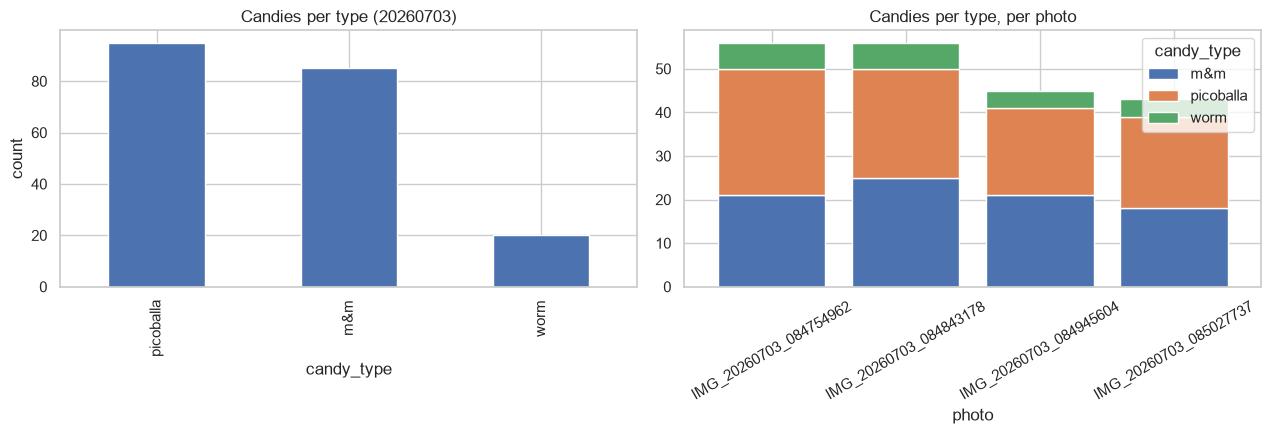

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

features_df["candy_type"].value_counts().plot.bar(ax=axes[0])
axes[0].set_title(f"Candies per type ({ANALYSIS_DATE})")
axes[0].set_ylabel("count")

pd.crosstab(features_df["source_image"], features_df["candy_type"]).plot.bar(
    stacked=True, ax=axes[1], width=0.8
)
axes[1].set_title("Candies per type, per photo")
axes[1].set_xlabel("photo")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 2. Reusable helpers

In [3]:
def crop_candy(source_image: str, label: int, bbox_margin: int = 4):
    image_path = next(CROP_DIR.glob(f"{source_image}.*"))
    mask_path = MASK_DIR / f"{source_image}_cp_masks.png"
    image = io.imread(image_path)
    mask = io.imread(mask_path)

    ys, xs = np.where(mask == label)
    y0, y1 = max(ys.min() - bbox_margin, 0), min(ys.max() + bbox_margin, mask.shape[0])
    x0, x1 = max(xs.min() - bbox_margin, 0), min(xs.max() + bbox_margin, mask.shape[1])

    crop = image[y0:y1, x0:x1].copy()
    crop[mask[y0:y1, x0:x1] != label] = 0
    return crop


def show_examples_by_group(df, group_col, n_examples=6, title=None, label_colors=None):
    """label_colors: optional {group_value: (r, g, b)} to color each row's label
    with that group's own mean color instead of an arbitrary one."""
    groups = sorted(df[group_col].dropna().unique(), key=str)
    fig, axes = plt.subplots(len(groups), n_examples, figsize=(2 * n_examples, 2 * len(groups)))
    axes = np.atleast_2d(axes)
    for row_i, group_value in enumerate(groups):
        subset = df[df[group_col] == group_value]
        examples = subset.sample(min(n_examples, len(subset)), random_state=0)
        for col_i in range(n_examples):
            ax = axes[row_i, col_i]
            ax.axis("off")
            if col_i < len(examples):
                row = examples.iloc[col_i]
                ax.imshow(crop_candy(row["source_image"], row["label"]))
            if col_i == 0:
                label_color = label_colors[group_value] if label_colors else "black"
                ax.set_ylabel(str(group_value), rotation=0, labelpad=45, fontsize=11,
                               color=label_color, fontweight="bold")
                ax.axis("on")
                ax.set_xticks([])
                ax.set_yticks([])
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def best_k_by_silhouette(X, k_range):
    scores = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)) for k in k_range}
    best_k = max(scores, key=scores.get)
    return best_k, scores


def cluster_rgb_hex(df, cluster_col, categories):
    """Each cluster's own mean RGB (0-1), as hex strings ordered to match `categories`
    (e.g. a categorical column's .cat.categories) -- for adata.uns[f"{col}_colors"]."""
    rgb = df.groupby(cluster_col)[["R_intensity_mean", "G_intensity_mean", "B_intensity_mean"]].mean() / 255
    hex_by_cluster = {c: matplotlib.colors.to_hex(tuple(rgb.loc[c])) for c in rgb.index}
    return rgb, [hex_by_cluster[c] for c in categories]


def plot_color_wheel_clusters(df, cluster_col, cluster_rgb, title):
    theta = df["hue_mean"] * 2 * np.pi
    point_colors = df[cluster_col].map(cluster_rgb.apply(tuple, axis=1))
    fig, ax = plt.subplots(figsize=(6, 5.5), subplot_kw={"projection": "polar"})
    ax.scatter(theta, df["saturation_mean"], c=list(point_colors), edgecolors="k", linewidths=0.5, s=45)
    ax.set_title(title)
    legend_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=cluster_rgb.loc[c], markeredgecolor="k",
                   markersize=9, label=f"cluster {c} (n={(df[cluster_col] == c).sum()})")
        for c in cluster_rgb.index
    ]
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.15, 1.05))
    plt.tight_layout()
    plt.show()


def plot_neighbor_graph(adata, source_image, ax, point_colors=None, type_col="candy_type"):
    """point_colors: optional {category_value: (r,g,b)} for true-color points;
    otherwise falls back to one matplotlib color per category."""
    idx = np.where(adata.obs["source_image"].to_numpy() == source_image)[0]
    sub_conn = adata.obsp["spatial_connectivities"][idx][:, idx].tocoo()
    coords = adata.obsm["spatial"][idx]
    types = adata.obs[type_col].to_numpy()[idx]

    for i, j in zip(sub_conn.row, sub_conn.col):
        if i < j:
            ax.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                    color="gray", linewidth=0.7, zorder=1)

    for category in np.unique(types):
        sel = types == category
        color = point_colors[category] if point_colors else None
        ax.scatter(coords[sel, 0], coords[sel, 1], label=str(category), color=color, s=45,
                   edgecolors="k" if point_colors else None, linewidths=0.5, zorder=2)

    ax.set_title(source_image)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")


## 3. Sub-classify the M&Ms by color

Every M&M has, by construction, roughly the same shape and low color heterogeneity —
the only thing left to distinguish them is *which* color they are, so we cluster on
hue/saturation directly.


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


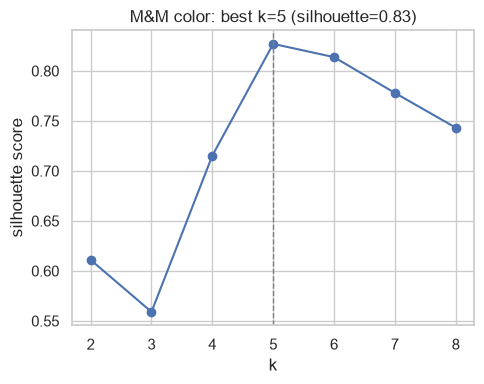

In [4]:
mm_df = features_df[features_df["candy_type"] == "m&m"].copy()
COLOR_FEATURES = ["hue_sin", "hue_cos", "saturation_mean"]

X_mm = StandardScaler().fit_transform(mm_df[COLOR_FEATURES])
best_k, scores = best_k_by_silhouette(X_mm, range(2, 9))

plt.figure(figsize=(5, 4))
plt.plot(list(scores.keys()), list(scores.values()), "o-")
plt.axvline(best_k, color="gray", linestyle="--", linewidth=1)
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title(f"M&M color: best k={best_k} (silhouette={scores[best_k]:.2f})")
plt.tight_layout()
plt.show()


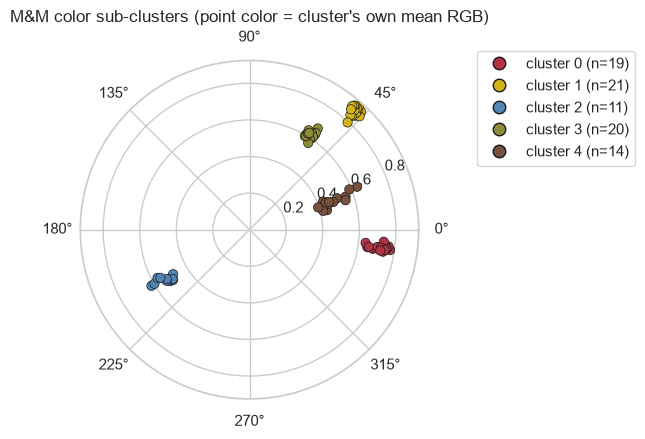

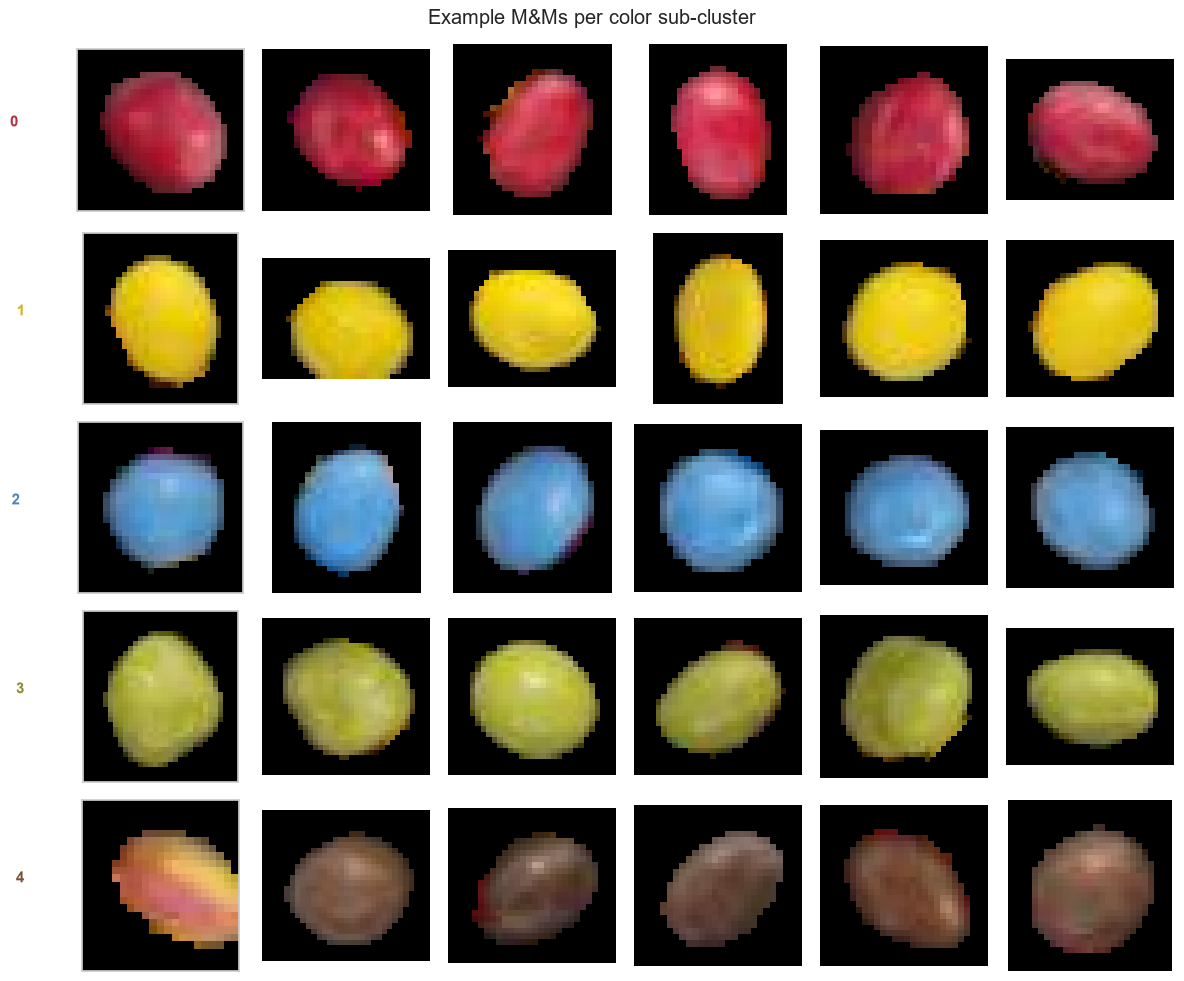

In [5]:
# TODO: override if you disagree with the automatic choice (compare against how many
# visually distinct M&M colors are actually in your photos)
N_MM_COLORS = best_k

mm_kmeans = KMeans(n_clusters=N_MM_COLORS, n_init=10, random_state=0)
mm_df["subtype_cluster"] = mm_kmeans.fit_predict(X_mm)
mm_df["fine_type"] = "m&m-" + mm_df["subtype_cluster"].astype(str)

mm_cluster_rgb, _ = cluster_rgb_hex(mm_df, "subtype_cluster", sorted(mm_df["subtype_cluster"].unique()))
plot_color_wheel_clusters(mm_df, "subtype_cluster", mm_cluster_rgb, "M&M color sub-clusters (point color = cluster's own mean RGB)")
show_examples_by_group(mm_df, "subtype_cluster", title="Example M&Ms per color sub-cluster",
                        label_colors=mm_cluster_rgb.apply(tuple, axis=1).to_dict())


## 4. Spatial neighborhood analysis with squidpy

Each photo is its own spatial context — candies from different photos were never
actually near each other, so neighbor graphs must be built *within* each photo, never
across photos. `squidpy` supports this natively via `library_key`.

We use a **Delaunay triangulation** for the neighbor graph rather than a fixed
"k nearest neighbors": candies aren't on a regular grid, so a triangulation adapts to
however densely they happen to be packed in a given photo, the same way it's commonly
used for irregularly-spaced cells in tissue.

### 4a. All candy types (coarse)

First, build the graph across *all* candies (worm / picoballa / M&M) and look at it.


In [6]:
X_adata = features_df[["aspect_ratio", "circularity", "color_std_mean", "area"]].to_numpy()
adata_all = ad.AnnData(X=X_adata, obs=features_df[["candy_id", "source_image", "candy_type"]].copy())
adata_all.obs["source_image"] = adata_all.obs["source_image"].astype("category")
adata_all.obs["candy_type"] = adata_all.obs["candy_type"].astype("category")
adata_all.obsm["spatial"] = features_df[["centroid-1", "centroid-0"]].to_numpy()  # (x, y) in cm

sq.gr.spatial_neighbors_delaunay(adata_all, library_key="source_image")
print(adata_all)
print(f"{adata_all.obsp['spatial_connectivities'].nnz} neighbor edges across {adata_all.obs['source_image'].nunique()} photos")


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Creating graph using `None` transform and `4` libraries.                                                  
AnnData object with n_obs × n_vars = 200 × 4
    obs: 'candy_id', 'source_image', 'candy_type'
    uns: 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'
1090 neighbor edges across 4 photos


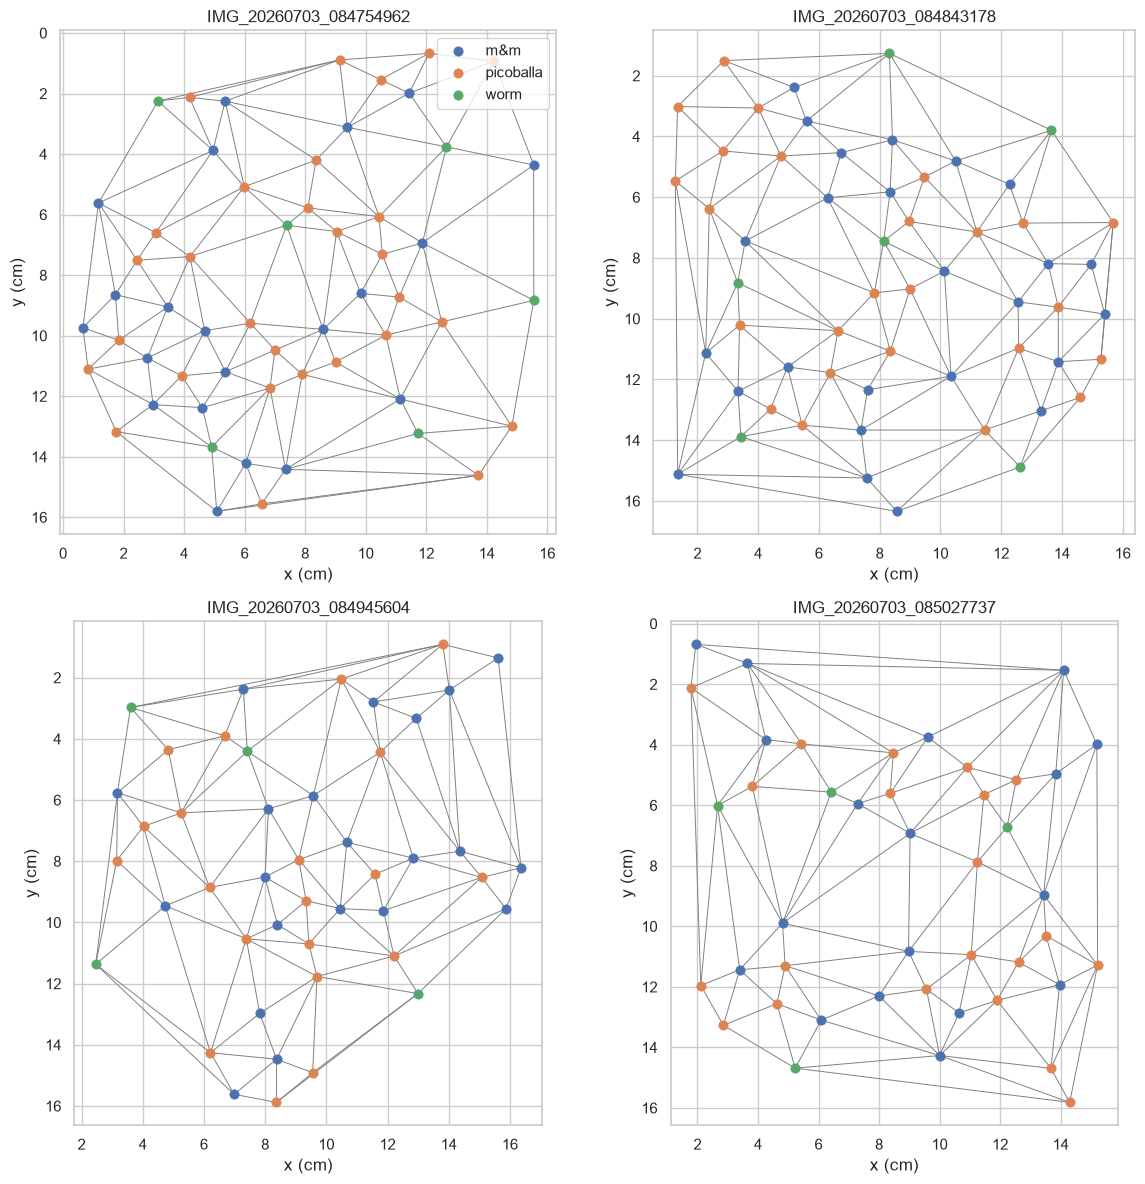

In [7]:
source_images = features_df["source_image"].unique()
n_cols = min(len(source_images), 2)
n_rows = int(np.ceil(len(source_images) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows), squeeze=False)
for ax, source_image in zip(axes.ravel(), source_images):
    plot_neighbor_graph(adata_all, source_image, ax, type_col="candy_type")
for ax in axes.ravel()[len(source_images):]:
    ax.axis("off")
axes.ravel()[0].legend(loc="upper right")
plt.tight_layout()
plt.show()


We don't run a formal enrichment test at this coarse level: worm/picoballa/M&M are
different candy species, trivially distinguishable by eye already, so confirming they
"cluster with their own kind" (or don't) isn't a very open question either way. The
more interesting question is below — do specific M&M *colors*, which look superficially
interchangeable at this level, actually clump together spatially?

### 4b. M&Ms only, by fine-grained color

**Caveat worth being explicit about:** building a fresh graph from *only* the M&M
points (rather than taking the full graph above and keeping M&M-M&M edges) changes
what "neighbor" means — two M&Ms with several picoballa/worms physically between them
on the paper can become Delaunay neighbors here, because those in-between candies are
no longer part of the graph at all. That's a real modeling choice, not just an
implementation detail — see the note in the last section.


In [8]:
X_adata_mm = mm_df[["aspect_ratio", "circularity", "color_std_mean", "area"]].to_numpy()
adata_mm = ad.AnnData(X=X_adata_mm, obs=mm_df[["candy_id", "source_image", "fine_type"]].copy())
adata_mm.obs["source_image"] = adata_mm.obs["source_image"].astype("category")
adata_mm.obs["fine_type"] = adata_mm.obs["fine_type"].astype("category")
adata_mm.obsm["spatial"] = mm_df[["centroid-1", "centroid-0"]].to_numpy()

# Use each subtype's own mean color everywhere it's plotted below, instead of an
# arbitrary categorical palette.
_, fine_type_hex = cluster_rgb_hex(mm_df, "subtype_cluster", [int(c.split("-")[1]) for c in adata_mm.obs["fine_type"].cat.categories])
adata_mm.uns["fine_type_colors"] = fine_type_hex
fine_type_rgb = dict(zip(adata_mm.obs["fine_type"].cat.categories, mm_cluster_rgb.apply(tuple, axis=1)))

sq.gr.spatial_neighbors_delaunay(adata_mm, library_key="source_image")
print(f"{adata_mm.obsp['spatial_connectivities'].nnz} M&M-only neighbor edges across {adata_mm.obs['source_image'].nunique()} photos")


INFO     Creating graph using `None` transform and `4` libraries.                                                  


C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit5\.pixi\envs\default\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


428 M&M-only neighbor edges across 4 photos


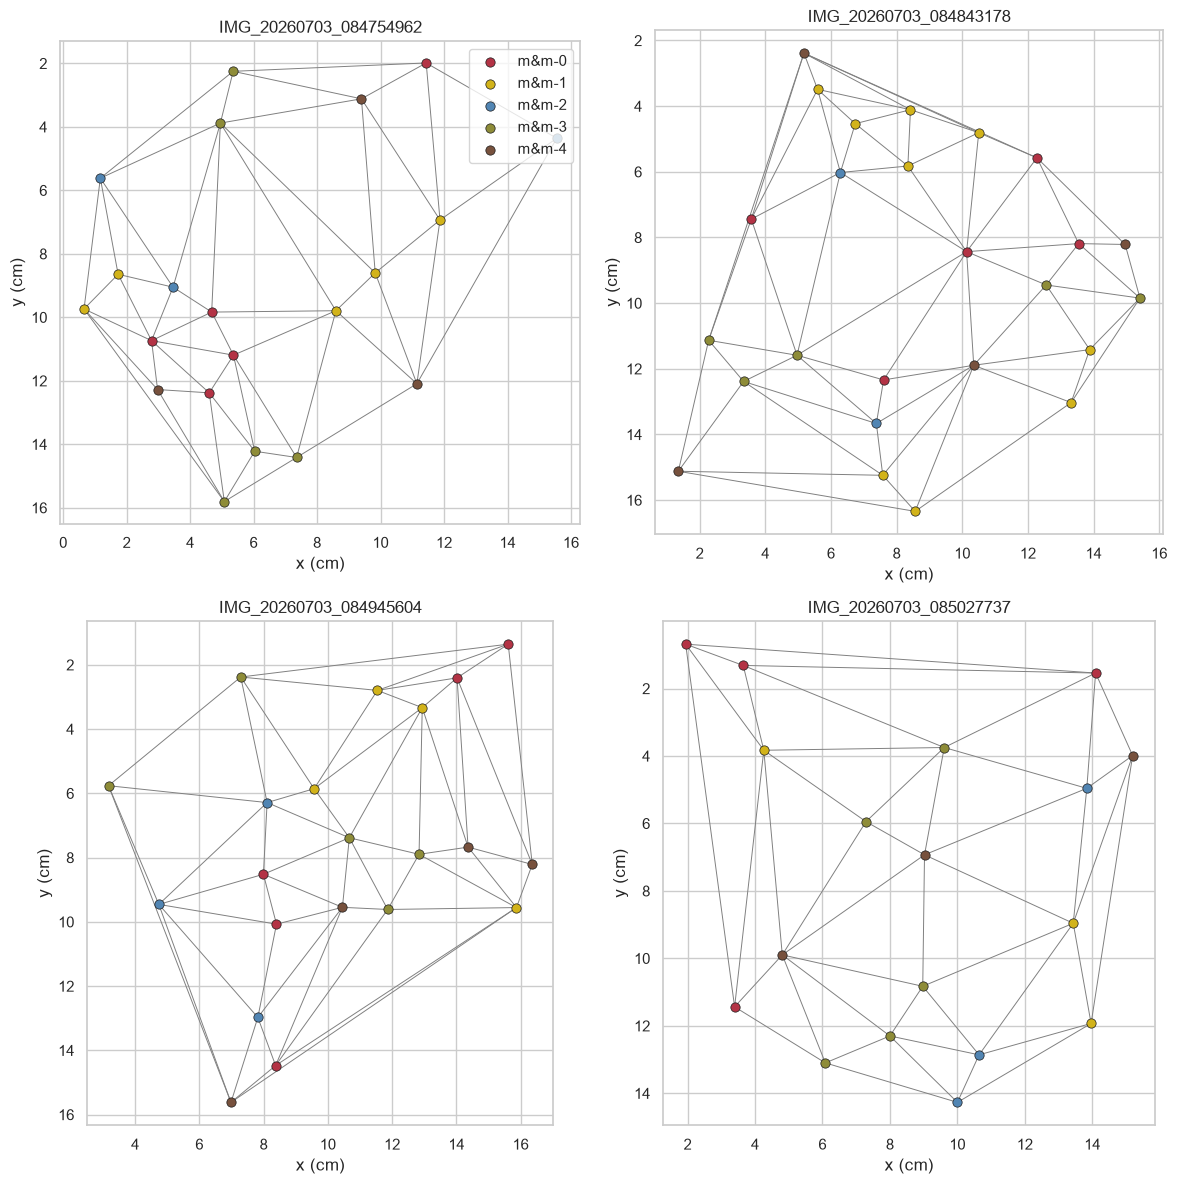

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows), squeeze=False)
for ax, source_image in zip(axes.ravel(), source_images):
    plot_neighbor_graph(adata_mm, source_image, ax, point_colors=fine_type_rgb, type_col="fine_type")
for ax in axes.ravel()[len(source_images):]:
    ax.axis("off")
axes.ravel()[0].legend(loc="upper right")
plt.tight_layout()
plt.show()


### Neighborhood enrichment (M&M color subtypes)

`sq.gr.nhood_enrichment` permutes the color labels many times, rebuilds the same graph
structure each time, and compares how often each pair of colors actually neighbors
each other against that random-shuffle baseline. A positive z-score means that pair
neighbors *more* than chance (co-located more than random); negative means *less*.

(`n_jobs=1` works around a Windows-specific crash in squidpy's parallel backend when
spawning worker processes from a notebook kernel — harmless here, the permutation test
still runs in a couple of seconds at this graph size.)


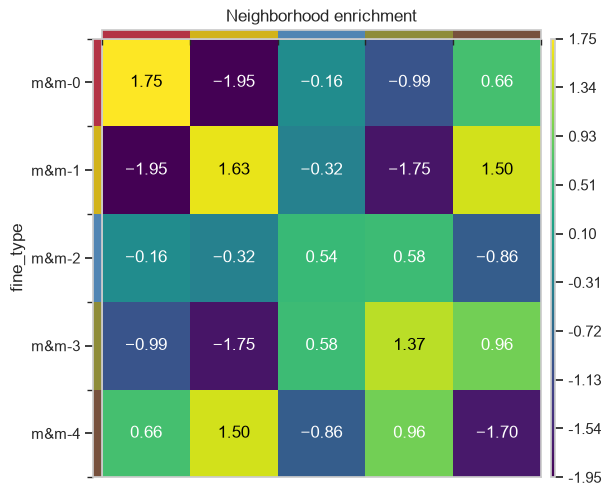

In [10]:
sq.gr.nhood_enrichment(adata_mm, cluster_key="fine_type", seed=0, n_jobs=1, show_progress_bar=False)

fig, ax = plt.subplots(figsize=(6, 5.5))
sq.pl.nhood_enrichment(adata_mm, cluster_key="fine_type", annotate=True, ax=ax)
plt.tight_layout()
plt.show()
